### Preface & Write up

In this analysis I use sentinel-2 level 2-A data from Copernicus to analyze the health of a segment of the Pisgah Forest using a Deep Learning Model. True Color, NDVI, and Moisture index bands are the inputs. The segment of the Pisgah forest was chosen somewhat arbitrarily due to interference patterns, satellite segmentation, and size was limited due to storage/compute bottlenecks. The current analysis only covers 4 years (2023-2026), and analyzes varying months in the late sprint/summer. Forest is identified within the U-Net as 10m area pixels, but are converted to hectares for interpretation. 

Note on model selection: Although raster differencing may be suitable for this analysis, Deep-Learning models are far more dynamic with regards to changing forest conditions, interference from shadows, elevation, and clouds, and doesn't rely on static definitions of "healthy" parameters. The U-Net utilized is the far more powerful tool, most suitable for time-varying and noisy patterns. 

Although changes were made since the presentation, (CORRINE weights used more efficiently identifying more forest and possibly exhibiting superior accuracy), we have determined that the U-Net Convolutional Neural Network was able to classify damaged/healthy areas of the forest given ground-truth availability limitations. If scaled with more compute, storage, observations, and ground truth baselines, this model could certainly be used to identify damaged areas of the forest and potentially inform policy.Examples of policies that may find use for this tool are: Forest/Community relief efforts after natural disasters, tracking the pest/fire/drought effects within forests, identification of areas where timber must be collected. 

I will continue this project with a team of my friends/colleauges. We will collect ground-truth samples, add more band wavelengths as inputs, scale compute and storage and thereby add more observations/area for more powerful and accurate analysis. 

### requirements

In [18]:
import torch
import torch.nn as nn
from torchvision import models
import rasterio
from rasterio.windows import from_bounds
import numpy as np
import os
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter
from matplotlib.patches import FancyBboxPatch, PathPatch
from matplotlib.path import Path
import plotly.graph_objects as go
import matplotlib.animation as animation
import matplotlib.patches as patches


### Unet architecture, tif loading, and unet implementation

*note the results are a good bit different from presentation. This is because I played around with the masks on the Corrine weights, and I believe the results are better as I specify alot more forest. I haven't added these tifs to the project as I still have ALOT of room to improve, but this is a nice step forward.*

In [ ]:
#simple unet class which I adapted took from documentation directly (definitely did not invent myself)
class SimpleUnet(nn.Module):
    def __init__(self, out_channels=15):
        super().__init__()
        base = models.resnet34(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-2])
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=1) 
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
#I have to use cpu, I have trash graphics processor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleUnet(out_channels=15).to(device)

#load CORRINE weights
weights_path = r"C:\Users\reyno\Downloads\corine_landcover\corine_landcover.pth"
if os.path.exists(weights_path):
    try:
        state_dict = torch.load(weights_path, map_location=device, weights_only=True)
        model.load_state_dict(state_dict, strict=False)
        print("Pretrained CORINE weights loaded successfully.")
    except Exception:
        state_dict = torch.load(weights_path, map_location=device, weights_only=False)
        model.load_state_dict(state_dict, strict=False)
        print("Pretrained CORINE weights loaded (Legacy Mode).")

model.eval()

#collect from different dates. The months are slightly different, but the model seems to differentiate okay
#wanted to be conservative and choose based on low interference over proximity to date,
#with more storage, compute, etc. we can just use all dates available. 
base_path = r"C:\Users\reyno\Downloads\Forest_Data"
years = {
    "2023": os.path.join(base_path, "2023-08-19"),
    "2024": os.path.join(base_path, "2024-08-19"), 
    "2025": os.path.join(base_path, "2025-05-19"),
    "2026": os.path.join(base_path, "2026-04-10")
}

#implementation of model on the given tifs
def deep_learning():
    ref_year = "2023"
    ref_files = [f for f in os.listdir(years[ref_year]) if "NDVI" in f]
    if not ref_files: return
    ref_file = os.path.join(years[ref_year], ref_files[0])
    
    with rasterio.open(ref_file) as ref:
        master_bounds = ref.bounds

    for year, folder in years.items():
        if not os.path.exists(folder): continue
        print(f"\nProcessing {year}...")
        
        files = os.listdir(folder)
        try:
            #collect true color, ndvi, moisture index if existing
            rgb_f = [os.path.join(folder, f) for f in files if "True_color" in f][0]
            ndvi_f = [os.path.join(folder, f) for f in files if "NDVI" in f][0]
            mi_f = [os.path.join(folder, f) for f in files if "Moisture_index" in f][0]
        except IndexError: 
            continue
        
        #match bounds to avoid mismatch in area of inference
        with rasterio.open(rgb_f) as rgb_src, rasterio.open(ndvi_f) as ndvi_src, rasterio.open(mi_f) as mi_src:
            win = from_bounds(*master_bounds, transform=rgb_src.transform)
            rgb_r = rgb_src.read([1,2,3], window=win, boundless=True, fill_value=0).astype('float32')
            ndvi_r = ndvi_src.read(1, window=win, boundless=True, fill_value=0).astype('float32')
            mi_r = mi_src.read(1, window=win, boundless=True, fill_value=0).astype('float32')
            
            #stretch to normalize data with 2-98% stretch
            rgb_input = np.zeros_like(rgb_r)
            for i in range(3):
                low, high = np.percentile(rgb_r[i], (2, 98))
                rgb_input[i] = np.clip((rgb_r[i] - low) / (high - low + 1e-6), 0, 1)

            input_tensor = torch.from_numpy(rgb_input).unsqueeze(0).to(device)
            
            #reduce abstraction, gain information via interpolation
            with torch.no_grad():
                output = model(input_tensor)
                output = F.interpolate(output, size=(ndvi_r.shape[0], ndvi_r.shape[1]), mode='bilinear', align_corners=False)
                pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            #check predictions and found classes (canopy type masks)
            found_classes = np.unique(pred)
            print(f"Detected Classes: {found_classes}")

            #used pretty broad classes, 0 shouldn't be forest and 1-14 are different
            #canopy/forest types in CORRINE
            is_forest = (pred >= 1) & (pred <= 14) 
            
            res = np.zeros(ndvi_r.shape, dtype=np.uint8)
            if np.any(is_forest):
                ndvi_stress_thresh = np.percentile(ndvi_r[is_forest], 15)
                mi_stress_thresh = np.percentile(mi_r[is_forest], 15)
                
                res[is_forest & (ndvi_r >= ndvi_stress_thresh) & (mi_r >= mi_stress_thresh)] = 1 
                res[is_forest & ((ndvi_r < ndvi_stress_thresh) | (mi_r < mi_stress_thresh))] = 2 

            #hectare calculations on healthy, damaged, total "forest" identified
            h_ha = (np.sum(res == 1) * 100) / 10000
            d_ha = (np.sum(res == 2) * 100) / 10000
            total_ha = h_ha + d_ha
            
            print(f"Detected Canopy: {total_ha:.1f} ha")
            print(f"Healthy: {h_ha:.1f} ha | Stressed: {d_ha:.1f} ha")

            out_meta = rgb_src.meta.copy()
            out_meta.update({
                "height": res.shape[0], "width": res.shape[1],
                "transform": rasterio.windows.transform(win, rgb_src.transform),
                "count": 1, "dtype": rasterio.uint8, "nodata": 0
            })
            with rasterio.open(f"Recovered_Health_{year}.tif", 'w', **out_meta) as dst:
                dst.write(res, 1)

if __name__ == "__main__":
    deep_learning()

Pretrained CORINE weights loaded successfully.

Processing 2023...
Detected Classes: [ 2  3  4  5  7  8  9 10 11 12 13 14]
Detected Canopy: 49650.0 ha
Healthy: 43262.4 ha | Stressed: 6387.6 ha

Processing 2024...
Detected Classes: [ 1  2  3  4  5  7  8  9 10 11 12 13 14]
Detected Canopy: 49650.0 ha
Healthy: 42641.4 ha | Stressed: 7008.6 ha

Processing 2025...
Detected Classes: [ 1  2  3  4  5  7  8  9 10 11 12 13 14]
Detected Canopy: 49650.0 ha
Healthy: 42229.5 ha | Stressed: 7420.5 ha

Processing 2026...
Detected Classes: [ 1  2  3  4  5  7  8  9 10 11 12 13 14]
Detected Canopy: 49650.0 ha
Healthy: 42473.2 ha | Stressed: 7176.9 ha


### Change map for transition states

In [ ]:
def change_map(year_start="2023", year_end="2024", timber_value_per_ha=2500):

    file_start = f"Recovered_Health_{year_start}.tif"
    file_end = f"Recovered_Health_{year_end}.tif"
    
    if not os.path.exists(file_start) or not os.path.exists(file_end):
        print(f"Error: Cannot find {file_start} or {file_end}.")
        return

    with rasterio.open(file_start) as src_start, rasterio.open(file_end) as src_end:
        #allignment for rasters error handling
        if src_start.shape != src_end.shape:
             print("Error: Raster dimensions do not match. Re-run alignment.")
             return
             
        mask_start = src_start.read(1)
        mask_end = src_end.read(1)
        
        meta = src_start.meta.copy()
        crs = src_start.crs

        # 0 = No Data/Non-Forest, 1 = Remained Healthy, 2 = New Stress, 3 = Recovery, 4 = Chronic Stress
        
        change_map = np.zeros(mask_start.shape, dtype=np.uint8)
        
        #define transition masks
        change_map[(mask_start == 1) & (mask_end == 1)] = 1
        change_map[(mask_start == 1) & (mask_end == 2)] = 2
        change_map[(mask_start == 2) & (mask_end == 1)] = 3
        change_map[(mask_start == 2) & (mask_end == 2)] = 4

        #convert pixels to hectares for metrics
        pixel_area_ha = (10 * 10) / 10000 
        
        new_stress_ha = np.sum(change_map == 2) * pixel_area_ha
        recovery_ha = np.sum(change_map == 3) * pixel_area_ha
        stable_asset_ha = np.sum(change_map == 1) * pixel_area_ha
        
        #metrics
        loss_value = new_stress_ha * timber_value_per_ha
        recovery_value = recovery_ha * timber_value_per_ha
        net_change_ha = recovery_ha - new_stress_ha
        net_value = net_change_ha * timber_value_per_ha
        
        print(f"\n==================================================")
        print(f"TIMBER HEALTH: {year_start} to {year_end}")
        print(f"==================================================")
        print(f"Recovery:      {recovery_ha:,.2f} ha  (+${(recovery_value/1e6):.2f}M)")
        print(f"New Risk:       {new_stress_ha:,.2f} ha  (-${(loss_value/1e6):.2f}M)")
        print(f"--------------------------------------------------")
        
        if net_change_ha > 0:
            print(f"NET CHANGE:          +{net_change_ha:,.2f} ha  (+${(net_value/1e6):.2f}M)")
        else:
            print(f"NET CHANGE:          {net_change_ha:,.2f} ha  (-${(abs(net_value)/1e6):.2f}M)")
        print(f"==================================================\n")

        #export change tif
        meta.update(
            dtype=rasterio.uint8, 
            count=1, 
            nodata=0,
            crs=crs # 
        )
        
        output_name = f"Forest_Change_{year_start}_{year_end}.tif"
        with rasterio.open(output_name, 'w', **meta) as dst:
            dst.write(change_map, 1)
            dst.write_colormap(1, {
                0: (0, 0, 0, 0),         # Transparent
                1: (34, 139, 34, 255),   # Forest Green (Stable)
                2: (255, 0, 0, 255),     # Red (New Stress)
                3: (0, 255, 255, 255),   # Cyan (Recovery)
                4: (139, 69, 19, 255)    # Brown (Chronic Stress)
            })
        print(f"Spatial layer exported: {output_name}")

if __name__ == "__main__":
    change_map(timber_value_per_ha=2500)


TIMBER HEALTH: 2023 to 2024
Recovery:      1,157.92 ha  (+$2.89M)
New Risk:       1,825.71 ha  (-$4.56M)
--------------------------------------------------
NET CHANGE:          -667.79 ha  (-$1.67M)

Spatial layer exported: Forest_Change_2023_2024.tif


### Transition Graph

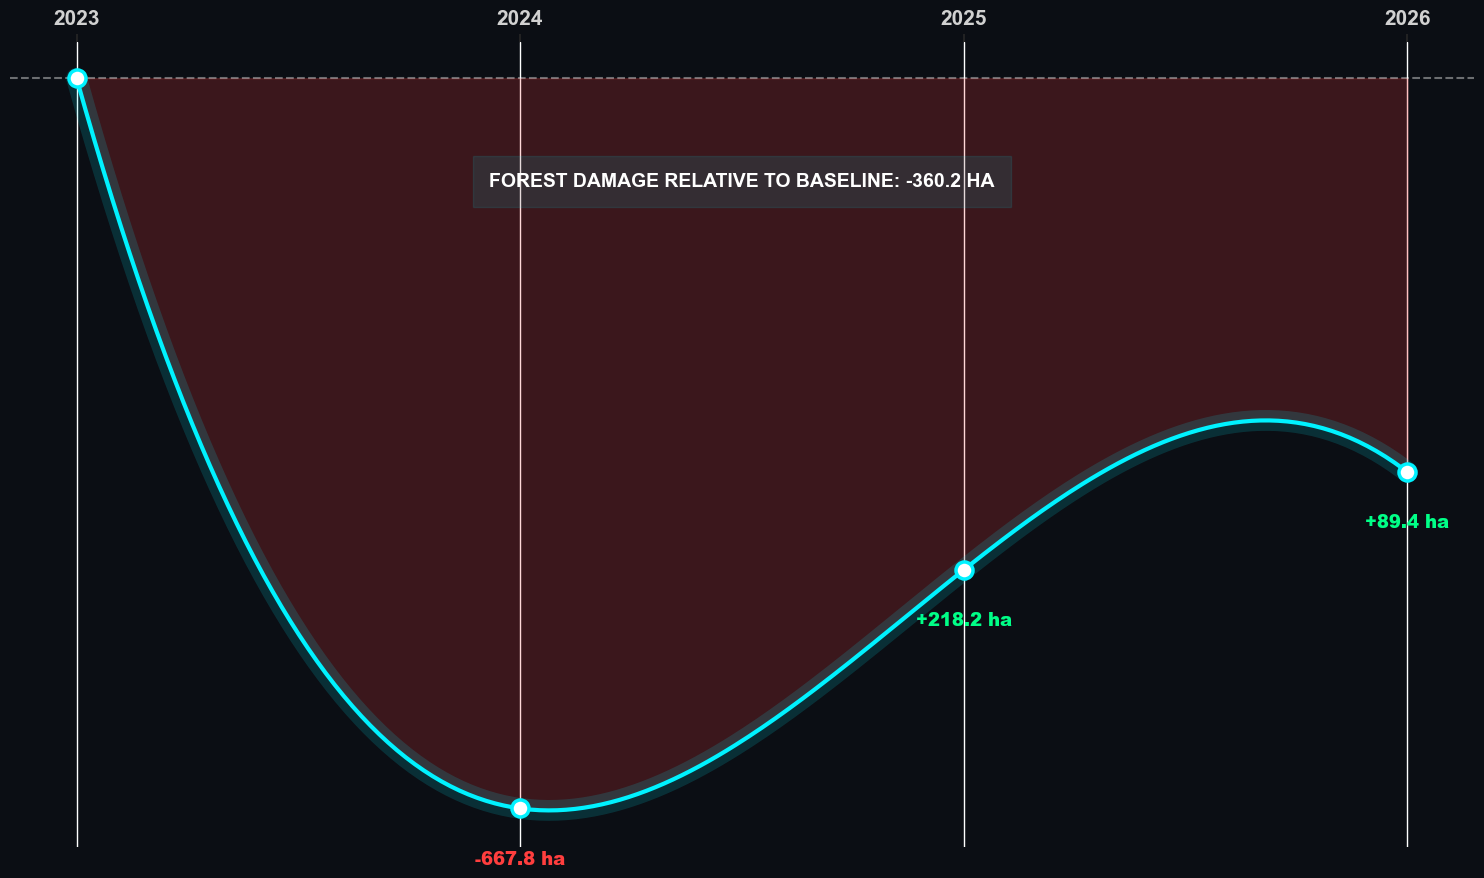

In [ ]:
def transition_analysis(map_paths):
    years = sorted(map_paths.keys())
    transition_results = []
    data = {year: rasterio.open(map_paths[year]).read(1) for year in years}
    
    cumulative_net = 0
    transition_results.append({"Year": "2023", "Net": 0, "Yearly_Change": 0})
    
    for i in range(len(years) - 1):
        y1, y2 = years[i], years[i+1]
        m1, m2 = data[y1], data[y2]
        deg_ha = np.sum((m1 == 1) & (m2 == 2)) * 0.01
        rec_ha = np.sum((m1 == 2) & (m2 == 1)) * 0.01
        yearly_change = rec_ha - deg_ha
        cumulative_net += yearly_change
        
        transition_results.append({
            "Year": y2, 
            "Net": cumulative_net,
            "Yearly_Change": yearly_change
        })
    return pd.DataFrame(transition_results)

paths = {"2023": "Recovered_Health_2023.tif", "2024": "Recovered_Health_2024.tif", 
         "2025": "Recovered_Health_2025.tif", "2026": "Recovered_Health_2026.tif"}
df = transition_analysis(paths)

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 9), facecolor='#0B0E14')
ax.set_facecolor('#0B0E14')

#adding a an arbitrarily smooth curve for visualization
#NOT ACCURATE TO FOREST STATE DAY TO DAY
x_numeric = np.arange(len(df))
x_smooth = np.linspace(x_numeric.min(), x_numeric.max(), 300)
spl = make_interp_spline(x_numeric, df['Net'], k=3)
y_smooth = spl(x_smooth)
ax.plot(x_smooth, y_smooth, color='#00F2FF', linewidth=3, alpha=1, zorder=5)
ax.plot(x_smooth, y_smooth, color='#00F2FF', linewidth=15, alpha=0.15, zorder=4)
ax.fill_between(x_smooth, y_smooth, 0, where=(y_smooth < 0), color='#FF3E3E', alpha=0.2, zorder=2)
ax.fill_between(x_smooth, y_smooth, 0, where=(y_smooth >= 0), color='#00FF87', alpha=0.2, zorder=2)

for i, row in df.iterrows():
    ax.scatter(i, row['Net'], color='white', s=150, edgecolors='#00F2FF', linewidth=2.5, zorder=6)
    
    if row['Year'] != "2023":
        text_color = '#FF3E3E' if row['Yearly_Change'] < 0 else '#00FF87'
        offset = 40 if row['Net'] >= 0 else -40
        
        ax.annotate(f"{row['Yearly_Change']:+.1f} ha", 
                    xy=(i, row['Net']), 
                    xytext=(0, offset),
                    textcoords="offset points",
                    ha='center', fontsize=13, fontweight='black', color=text_color)

ax.xaxis.tick_top()
ax.set_xticks(x_numeric)
ax.set_xticklabels(df['Year'], color='#D1D1D1', fontsize=15, fontweight='bold')


total_net = df['Net'].iloc[-1]
stats_text = f"FOREST DAMAGE RELATIVE TO BASELINE: {total_net:+.1f} HA"
plt.text(0.5, 0.82, stats_text, transform=ax.transAxes,
         color='white', fontsize=14, fontweight='bold', ha='center',
         bbox=dict(facecolor='#00F2FF', alpha=0.1, edgecolor='#00F2FF', pad=12))

ax.axhline(0, color='white', alpha=0.4, linewidth=1.5, linestyle='--')
ax.get_yaxis().set_visible(False)
for spine in ax.spines.values(): spine.set_visible(False)


plt.tight_layout()
plt.savefig("clemson_forest_pulse_final_v3.png", dpi=300)
plt.show()

### Flow Diagram

In [ ]:
def generate_sankey_data(df):
    #Mapping transitions into a flow format
    #2023 Healthy -> 2024 Stressed
    #2024 Stressed -> 2026 Recovered
    #excluded 2025 as flow chart was more difficult to interpret with 4 states. 
    
    label = ["2023 Healthy", "2023 Stressed", "2024 Healthy", "2024 Stressed", "2026 Healthy", "2026 Stressed"]
    source = [0, 0, 1, 3, 3, 2] 
    target = [2, 3, 5, 4, 5, 4]
    value = [21000, 1825, 500, 1157, 668, 20500] #hectares
    
    fig = go.Figure(data=[go.Sankey(
        node = dict(
          pad = 15,
          thickness = 20,
          line = dict(color = "black", width = 0.5),
          label = label,
          color = ["#2ecc71", "#e74c3c", "#27ae60", "#c0392b", "#00FF87", "#FF3E3E"]
        ),
        link = dict(
          source = source,
          target = target,
          value = value,
          color = 'rgba(46, 204, 113, 0.2)'
      ))])

    fig.update_layout(title_text="Transition Flow: Forest Recovery and Lasting Damage", font_size=12, template='plotly_dark')
    fig.write_html("transition_flow.html")

generate_sankey_data(None)

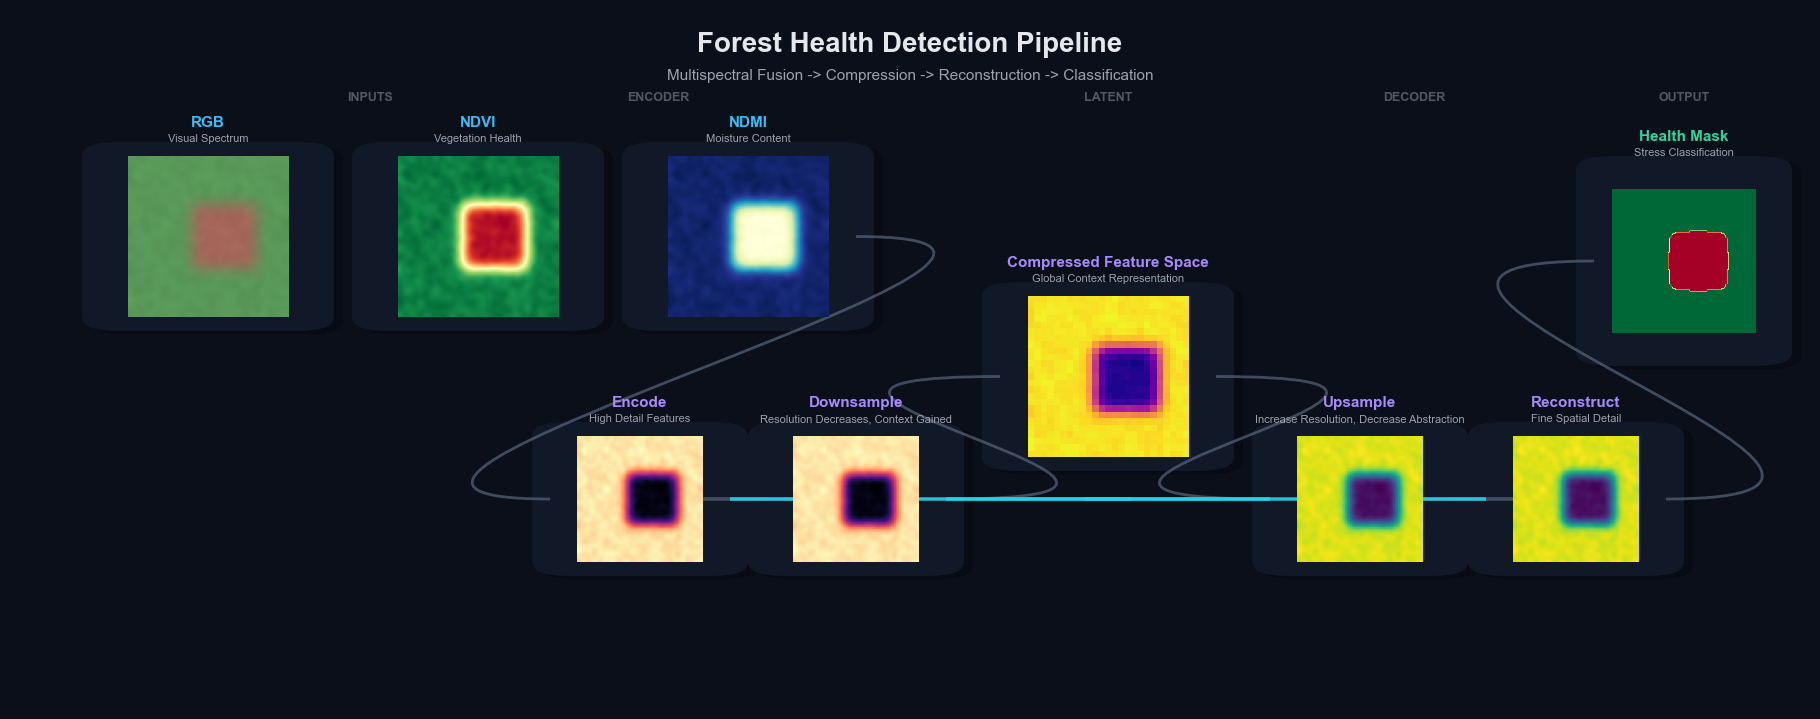

In [ ]:
def timber_viz():
    bg = '#0B0F1A'
    card = '#111827'
    text = '#E5E7EB'
    subtext = '#9CA3AF'

    c_input = '#38BDF8'
    c_model = '#A78BFA'
    c_output = '#34D399'
    c_skip = '#22D3EE'

    fig = plt.figure(figsize=(18, 7), facecolor=bg)
    ax = plt.axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    np.random.seed(42)
    size = 100
    forest = gaussian_filter(np.random.rand(size, size), sigma=2)

    stress = np.zeros((size, size))
    stress[30:70, 40:80] = 1
    stress = gaussian_filter(stress, sigma=4)

    rgb = np.clip(np.stack([
        0.3 + forest*0.1 + stress*0.3,
        0.5 + forest*0.2 - stress*0.2,
        0.3 + forest*0.1
    ], axis=-1), 0, 1)

    ndvi = np.clip(0.6 + forest*0.2 - stress*0.5, 0, 1)
    ndmi = np.clip(0.5 + forest*0.2 - stress*0.6, 0, 1)
    mask = (stress > 0.45).astype(float)


    def card_box(x, y, w, h, title, subtitle="", img=None, cmap=None, accent=None):

        shadow = FancyBboxPatch(
            (x+0.005, y-0.005), w, h,
            boxstyle="round,pad=0.01,rounding_size=0.02",
            linewidth=0, facecolor='black', alpha=0.25
        )
        ax.add_patch(shadow)


        box = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.01,rounding_size=0.02",
            linewidth=0, facecolor=card
        )
        ax.add_patch(box)

 
        ax.text(x + w/2, y + h + 0.028, title,
                ha='center', va='bottom',
                color=accent if accent else text,
                fontsize=11, fontweight='semibold')


        if subtitle:
            ax.text(x + w/2, y + h + 0.008, subtitle,
                    ha='center', va='bottom',
                    color=subtext,
                    fontsize=8)


        if img is not None:
            ax_img = fig.add_axes([x+0.01, y+0.01, w-0.02, h-0.02])
            ax_img.imshow(img, cmap=cmap)
            ax_img.axis('off')

        return (x, y, w, h)


    boxes = {}

    boxes['rgb'] = card_box(
        0.05, 0.55, 0.12, 0.25,
        "RGB",
        "Visual Spectrum",
        rgb, accent=c_input
    )

    boxes['ndvi'] = card_box(
        0.20, 0.55, 0.12, 0.25,
        "NDVI",
        "Vegetation Health",
        ndvi, 'RdYlGn', c_input
    )

    boxes['ndmi'] = card_box(
        0.35, 0.55, 0.12, 0.25,
        "NDMI",
        "Moisture Content",
        ndmi, 'YlGnBu', c_input
    )

    boxes['enc1'] = card_box(
        0.30, 0.20, 0.10, 0.20,
        "Encode",
        "High Detail Features",
        ndvi, 'magma', c_model
    )

    boxes['enc2'] = card_box(
        0.42, 0.20, 0.10, 0.20,
        "Downsample",
        "Resolution Decreases, Context Gained",
        ndvi[::2, ::2], 'magma', c_model
    )

    boxes['latent'] = card_box(
        0.55, 0.35, 0.12, 0.25,
        "Compressed Feature Space",
        "Global Context Representation",
        ndvi[::4, ::4], 'plasma', c_model
    )


    boxes['dec2'] = card_box(
        0.70, 0.20, 0.10, 0.20,
        "Upsample",
        "Increase Resolution, Decrease Abstraction",
        ndvi[::2, ::2], 'viridis', c_model
    )

    boxes['dec1'] = card_box(
        0.82, 0.20, 0.10, 0.20,
        "Reconstruct",
        "Fine Spatial Detail",
        ndvi, 'viridis', c_model
    )

    boxes['out'] = card_box(
        0.88, 0.50, 0.10, 0.28,
        "Health Mask",
        "Stress Classification",
        mask, 'RdYlGn_r', c_output
    )


    def connect(a, b, color='#64748B', lw=2, curve=0.2, alpha=0.6):
        x1, y1, w1, h1 = boxes[a]
        x2, y2, w2, h2 = boxes[b]

        p1 = (x1 + w1, y1 + h1/2)
        p2 = (x2, y2 + h2/2)

        verts = [
            p1,
            (p1[0] + curve, p1[1]),
            (p2[0] - curve, p2[1]),
            p2
        ]

        path = Path(verts, [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
        patch = PathPatch(path, facecolor='none', edgecolor=color, lw=lw, alpha=alpha)
        ax.add_patch(patch)

    connect('ndmi', 'enc1')
    connect('enc1', 'enc2')
    connect('enc2', 'latent')
    connect('latent', 'dec2')
    connect('dec2', 'dec1')
    connect('dec1', 'out')

    connect('enc1', 'dec1', color=c_skip, lw=2.5, curve=0.35, alpha=0.9)
    connect('enc2', 'dec2', color=c_skip, lw=2.5, curve=0.25, alpha=0.9)

    def stage_label(x, label):
        ax.text(x, 0.87, label,
                ha='center',
                color=subtext,
                fontsize=9,
                alpha=0.5,
                fontweight='bold')

    stage_label(0.20, "INPUTS")
    stage_label(0.36, "ENCODER")
    stage_label(0.61, "LATENT")
    stage_label(0.78, "DECODER")
    stage_label(0.93, "OUTPUT")

    ax.text(0.5, 0.94, "Forest Health Detection Pipeline",
            ha='center', color=text, fontsize=20, fontweight='bold')

    ax.text(0.5, 0.90,
            "Multispectral Fusion -> Compression -> Reconstruction -> Classification",
            ha='center', color=subtext, fontsize=11)

    plt.show()

timber_viz()

### Cool Gif to give intuition on how the classifier scans input tif

In [ ]:
def gif():

    np.random.seed(42)
    grid_size = 100
    
    base_img = np.random.rand(grid_size, grid_size, 3) * 0.5
    base_img[:,:,1] += 0.3 
    satellite_img = gaussian_filter(base_img, sigma=2)
    satellite_img = np.clip(satellite_img, 0, 1)
    

    mask_noise = gaussian_filter(np.random.rand(grid_size, grid_size), sigma=4)
    health_mask = np.where(mask_noise > 0.55, 1, 0)

    bg_color = '#0B0F19'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor=bg_color)
    fig.suptitle('Forest Health Inference with U-Net', color='white', fontsize=18, fontweight='black', y=0.95)
    
    for ax in [ax1, ax2]:
        ax.set_facecolor(bg_color)
        ax.axis('off')

    ax1.set_title("Multispectral Satellite Imagery", color='#94A3B8', pad=10)
    ax2.set_title("Classified Forest", color='#94A3B8', pad=10)

    ax1.imshow(satellite_img)
    
    blank_mask = np.zeros((grid_size, grid_size, 4)) 
    mask_display = ax2.imshow(blank_mask)

    window_size = 20
    stride = 10

    scanner_glow = patches.Rectangle((0, 0), window_size, window_size, linewidth=6, edgecolor='#0EA5E9', facecolor='none', alpha=0.3)
    scanner_core = patches.Rectangle((0, 0), window_size, window_size, linewidth=2, edgecolor='#0EA5E9', facecolor='none')
    ax1.add_patch(scanner_glow)
    ax1.add_patch(scanner_core)

    coords = []
    for y in range(0, grid_size - window_size + 1, stride):
        for x in range(0, grid_size - window_size + 1, stride):
            coords.append((x, y))

    def animate(frame):
        if frame < len(coords):
            x, y = coords[frame]
            
            scanner_glow.set_xy((x, y))
            scanner_core.set_xy((x, y))
            
            for i in range(y, y + window_size):
                for j in range(x, x + window_size):
                    if health_mask[i, j] == 1:
                        blank_mask[i, j] = [239/255, 68/255, 68/255, 1.0] # Red
                    else:
                        blank_mask[i, j] = [16/255, 185/255, 129/255, 1.0] # Green
            
            mask_display.set_data(blank_mask)
            
        return scanner_glow, scanner_core, mask_display

    ani = animation.FuncAnimation(fig, animate, frames=len(coords)+5, interval=80, blit=True)
    
    writer = animation.PillowWriter(fps=15, bitrate=1800)
    ani.save('deep_learning_inference.gif', writer=writer)
    plt.close()
    print("Saved as 'deep_learning_inference.gif'")

gif()

Saved as 'deep_learning_inference.gif'
